In [5]:
from pymongo import MongoClient
from dotenv import load_dotenv
import pandas as pd
import os

load_dotenv(".env")

client = MongoClient(os.getenv("MONGO_URI"))

db = client[os.getenv("MONGO_DB_NAME")]

coleccion = db[os.getenv("MONGO_COLLECTION_PROCESSED")]

In [6]:
datos = list(
    coleccion.find(
        {},
        {
            "_id":0,
            "precio":1,
            "m2":1,
            "dormitorios":1,
            "banos":1
        }
    )
)

df = pd.DataFrame(datos)

print(df.shape)

df.head()

(1926, 4)


,banos,dormitorios,m2,precio
0,1,1,54,620000
1,2,3,80,600000
2,1,2,54,550000
3,2,2,68,630000
4,1,3,50,380000


In [8]:
df = df.dropna()

df = df[
    (df["precio"] > 0)
    & (df["m2"] > 0)
]

print(df.shape)

(1926, 4)


In [11]:
from sklearn.preprocessing import StandardScaler

variables = df[
    ["precio","m2","dormitorios","banos"]
]

scaler = StandardScaler()

X = scaler.fit_transform(variables)

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercias = []

for k in range(1,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X)

    inercias.append(modelo.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inercias,
    marker="o"
)

plt.xlabel("Número de Clusters")

plt.ylabel("Inercia")

plt.title("Método del Codo")

plt.show()

NameError: name 'X' is not defined

In [12]:
from pymongo import MongoClient
from dotenv import load_dotenv
import pandas as pd
import os

load_dotenv(".env")

client = MongoClient(os.getenv("MONGO_URI"))

db = client[os.getenv("MONGO_DB_NAME")]

coleccion = db[os.getenv("MONGO_COLLECTION_PROCESSED")]

datos = list(
    coleccion.find(
        {},
        {
            "_id":0,
            "precio":1,
            "m2":1,
            "dormitorios":1,
            "banos":1
        }
    )
)

df = pd.DataFrame(datos)

df = df.dropna()

df = df[
    (df["precio"] > 0)
    & (df["m2"] > 0)
]

print(df.shape)

(1926, 4)


In [13]:
from sklearn.preprocessing import StandardScaler

variables = df[
    ["precio","m2","dormitorios","banos"]
]

scaler = StandardScaler()

X = scaler.fit_transform(variables)

print(X.shape)

(1926, 4)


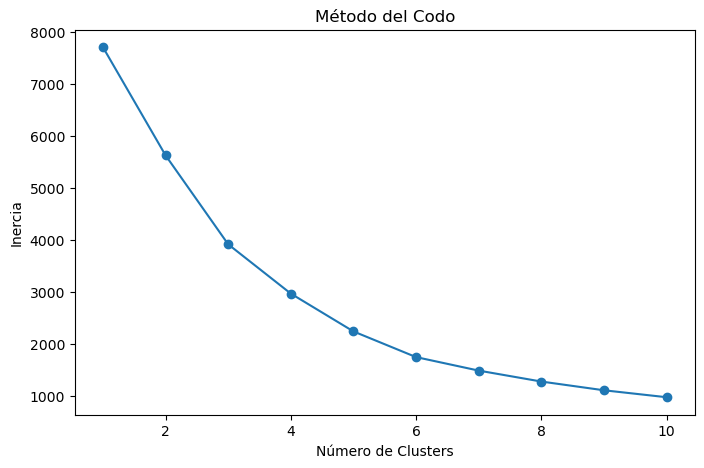

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercias = []

for k in range(1,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X)

    inercias.append(modelo.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inercias,
    marker="o"
)

plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")

plt.show()

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

df["cluster"] = clusters